In [1]:
import numpy as np
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import scienceplots
plt.style.use(['science','no-latex'])

In [5]:
barTNG100 = h5py.File('./data/tng100-1_bar_size.hdf5','r')
barTNG50 = h5py.File('./data/tng50-1_bar_size.hdf5','r')

In [6]:
TNG50visual=[63877,117254,117266,167405,198184,220600,264888,275549,294869,360925,443050,496789,499022,
 528836,531910,547546,553231,553837,566661,574615,575596,577125,582344,583745,587819,588647,590218,597141,
 598320,601997,605708,613006,617719,619081,619223,620463,621167,629266,630870,630975,632310,635905,642220,
 643642,652267]
TNG50_table = pd.DataFrame()

TNG50_ID = barTNG50['gal_ID'][...]
TNG50_M30 = barTNG50['Snapshot_99']['stellar_mass'][...]
TNG50_barflag = barTNG50['Snapshot_99']['Ellipse_cut_0.6']['Barflag'][...]
TNG50_barlength = np.max([barTNG50['Snapshot_99']['Ellipse_cut_0.6']['R_bar'][...],
                          barTNG50['Snapshot_99']['Ellipse_cut_1.4']['R_bar'][...]],axis=0)
TNG50_barflag[np.isin(TNG50_ID,TNG50visual)]=0
TNG50_barlength[TNG50_barflag!=1]=0

TNG50_table['gal_ID'] = TNG50_ID

for i in ['krot','stellar_mass']:
    TNG50_table[i] = barTNG50['Snapshot_99'][i][...]

TNG50_table['Rbar'] = TNG50_barlength


bins=[10.0,10.1,10.2,10.3,10.5,10.7,10.9,11.1]
labels= np.arange(len(bins)-1)
TNG50_table['mass_grade']=pd.cut(x=TNG50_table['stellar_mass'],bins=bins,labels=labels,include_lowest=True)


TNG50_Q30=TNG50_table[TNG50_table['Rbar']>0].groupby(by='mass_grade',observed=True).quantile(0.16)
TNG50_Q50=TNG50_table[TNG50_table['Rbar']>0].groupby(by='mass_grade',observed=True).quantile(0.5)
TNG50_Q70=TNG50_table[TNG50_table['Rbar']>0].groupby(by='mass_grade',observed=True).quantile(0.84)

In [31]:
TNG100visual =[466436, 502279, 408076, 121875, 383508, 499223, 488500, 265269,
       265268, 360510, 497220, 514127, 517199, 470617, 518236, 489054,
       540767, 125033, 495214, 429680, 393337, 269441, 376963, 499852,
       175245, 539284, 446612, 279709, 345251, 295079, 421032, 455857,
       474813, 476362, 181987, 406256, 273142, 499960, 297211,  96510,
       523008, 535817, 467212, 448269, 407321, 492825, 523035, 483113,
       492845, 367931, 508748, 439631, 535887, 210769, 498520, 523109,
       511858, 449910, 513402, 378749, 386429, 517503, 492425, 529804,
       510861, 128399, 128400, 314772, 336276, 510362, 427419, 477089,
       376739, 473004, 493491, 337845, 364480, 520649, 527306, 466387,
       494036, 502232, 500188, 131050, 526833]


TNG100_table = pd.DataFrame()

TNG100_ID = barTNG100['gal_ID'][...]
TNG100_M30 = barTNG100['Snapshot_99']['stellar_mass'][...]
TNG100_barflag = barTNG100['Snapshot_99']['Ellipse_cut_1.4']['Barflag'][...]
TNG100_barlength =barTNG100['Snapshot_99']['Ellipse_cut_1.4']['R_bar'][...]
TNG100_barflag[np.isin(TNG100_ID,TNG100visual)]=0
TNG100_barlength[TNG100_barflag!=1]=0

TNG100_table['gal_ID'] = TNG100_ID
for i in ['krot','stellar_mass']:
    TNG100_table[i] = barTNG100['Snapshot_99'][i][...]

TNG100_table['Rbar'] = TNG100_barlength

bins=[10.4,10.5,10.7,10.9,11.1]
labels= np.arange(len(bins)-1)
TNG100_table['mass_grade']=pd.cut(x=TNG100_table['stellar_mass'],bins=bins,labels=labels,include_lowest=True)

TNG100_Q30=TNG100_table[TNG100_table['Rbar']>0].groupby(by='mass_grade',observed=True).quantile(0.16)
TNG100_Q50=TNG100_table[TNG100_table['Rbar']>0].groupby(by='mass_grade',observed=True).quantile(0.5)
TNG100_Q70=TNG100_table[TNG100_table['Rbar']>0].groupby(by='mass_grade',observed=True).quantile(0.84)

In [32]:
short20z=np.polyfit([10.6,11.3],np.log10([1.622,4]),1)
short20z[1]=short20z[1]+np.log10(1/0.6774)

In [33]:
short20z=np.polyfit([10.6,11.3],np.log10([1.622,4]),1) #np.array([ 0.56001306, -5.55693277])
short20z[1]=short20z[1]+np.log10(1/0.6774)  
short10z=np.polyfit([10.6,11.3],np.log10([1.622,4]),1) #np.array([ 0.56001306, -5.72608758])

In [34]:
s4gdisk = pd.read_csv('./data/s4gbars_table.dat',comment='#',sep='\s+')

s4gdisk=s4gdisk[(s4gdisk['logmstar']>10)&(s4gdisk['logmstar']<11.2)].copy()
s4gbar=s4gdisk[(s4gdisk['sma_dp_kpc2']>0)&(s4gdisk['logmstar']>10)&(s4gdisk['logmstar']<11.2)].copy()

In [35]:
TNG50_table['short10']=0
TNG50_table.loc[TNG50_table[np.log10(TNG50_table['Rbar'])>(short10z[0]*TNG50_table['stellar_mass']+short10z[1])].index,'short10']=1
TNG50_table['short20']=0
TNG50_table.loc[TNG50_table[np.log10(TNG50_table['Rbar'])>(short20z[0]*TNG50_table['stellar_mass']+short20z[1])].index,'short20']=1

/home/yxi/anaconda3/envs/anasim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yxi/anaconda3/envs/anasim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [36]:
TNG100_table['short10']=0
TNG100_table.loc[TNG100_table[(np.log10(TNG100_table['Rbar'])>(short10z[0]*TNG100_table['stellar_mass']+short10z[1]))
                              &(TNG100_table['Rbar']>0)].index,'short10']=1
TNG100_table['short20']=0
TNG100_table.loc[TNG100_table[(np.log10(TNG100_table['Rbar'])>(short20z[0]*TNG100_table['stellar_mass']+short20z[1]))
                              &(TNG100_table['Rbar']>0)].index,'short20']=1

/home/yxi/anaconda3/envs/anasim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yxi/anaconda3/envs/anasim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [37]:
massesrange=np.array([10,10.2,10.4,10.6,10.8,11.0])

In [38]:
massmin = np.array([10,10.2,10.4,10.6,10.8,11.0])
massmax = np.array([10.2,10.4,10.6,10.8,11.0,11.1])

In [39]:
f50allbar=[]
f50normalbar=[]
f50_10thbar=[]

fS4Gbar=[]

Num_TNG50_allbar=[]
Num_TNG50_disk = []
Num_TNG50_normalbar=[]
Num_S4Gbar=[]

f100allbar_update=[]
f100normalbar_update=[]
f100_10thbar_update=[]
Num_TNG100_allbar_update=[]
Num_TNG100_normalbar_update=[]
Num_TNG100_disk_update = []

for i,j in zip(massmin,massmax):
    if i<10.4:
        pass
    else:
        i_TNG100disk=len(TNG100_table[(TNG100_table['stellar_mass']>i)&(TNG100_table['stellar_mass']<j)].index)
        i_TNG100allbar=len(TNG100_table[(TNG100_table['Rbar']>0)&(TNG100_table['stellar_mass']>i)&(TNG100_table['stellar_mass']<j)].index)
        i_TNG100normalbar=len(TNG100_table[(TNG100_table['short20']==1)&(TNG100_table['stellar_mass']>i)&(TNG100_table['stellar_mass']<j)].index)
        i_TNG100_10th=len(TNG100_table[(TNG100_table['short10']==1)&(TNG100_table['stellar_mass']>i)&(TNG100_table['stellar_mass']<j)].index)
        f100allbar_update.append(i_TNG100allbar/i_TNG100disk)
        f100normalbar_update.append(i_TNG100normalbar/i_TNG100disk)
        f100_10thbar_update.append(i_TNG100_10th/i_TNG100disk)
        Num_TNG100_allbar_update.append(i_TNG100allbar)
        Num_TNG100_normalbar_update.append(i_TNG100normalbar)
        Num_TNG100_disk_update.append(i_TNG100disk)
    
    i_TNG50disk=len(TNG50_table[(TNG50_table['stellar_mass']>i)&(TNG50_table['stellar_mass']<j)].index)
    i_TNG50allbar=len(TNG50_table[(TNG50_table['Rbar']>0)&(TNG50_table['stellar_mass']>i)&(TNG50_table['stellar_mass']<j)].index)
    i_TNG50normalbar=len(TNG50_table[(TNG50_table['Rbar']>0)&(TNG50_table['short20']==1)&(TNG50_table['stellar_mass']>i)&(TNG50_table['stellar_mass']<j)].index)
    
    i_TNG50_10th=len(TNG50_table[(TNG50_table['Rbar']>0)&(TNG50_table['short10']==1)&(TNG50_table['stellar_mass']>i)&(TNG50_table['stellar_mass']<j)].index)
    
    i_S4Gdisk=len(s4gdisk[(s4gdisk['logmstar']>i)&(s4gdisk['logmstar']<j)].index)
    i_S4Gbar=len(s4gbar[(s4gbar['logmstar']>i)&(s4gbar['logmstar']<j)].index)
    
    Num_TNG50_disk.append(i_TNG50disk)
    Num_TNG50_allbar.append(i_TNG50allbar)
    Num_TNG50_normalbar.append(i_TNG50normalbar)

    Num_S4Gbar.append(i_S4Gbar)

    f50allbar.append(i_TNG50allbar/i_TNG50disk)
    f50normalbar.append(i_TNG50normalbar/i_TNG50disk)
    f50_10thbar.append(i_TNG50_10th/i_TNG50disk)

    fS4Gbar.append(i_S4Gbar/i_S4Gdisk)

In [40]:
# from https://github.com/perwin/s4g_barfractions/tree/master/data
obs10y=[0.0160007,0.04124628,0.05686056,0.07741958,0.102117,0.141841,0.1788313,0.2042135,0.2571202,0.331329,0.4636134]
obs10x=[10.004,10.109,10.157,10.212,10.273,10.362,10.437,10.485,10.578,10.696,10.881]
obs90y=[0.4448549, 0.4796605,0.4974098,0.519252,0.5455291,0.5873814,0.6255253,0.6512906,0.7045392,0.77834,0.9078075]
obs90x=[10.004,10.109,10.157,10.212,10.273,10.362,10.437,10.485,10.578,10.696,10.881]

In [41]:
obs10z=np.asarray(np.polyfit(obs10x,obs10y,1))
obs90z=np.asarray(np.polyfit(obs90x,obs90y,1))

In [42]:
obs10x1=[10.0,11.1]
obs10y1=np.asarray(obs10x1)*obs10z[0]+obs10z[1]

In [43]:
obs90x1=[10.0,11.1]
obs90y1=np.asarray(obs90x1)*obs90z[0]+obs90z[1]

In [44]:
bestfit_a=-0.42+(0.07-0.56)*10.11
bestfit_b=0.56

fit_y=np.asarray(obs10x1)*bestfit_b+bestfit_a

fS4Gfit_x=np.linspace(10.0, 11.1, 100)
fS4Gfit_y=1/(1+np.exp(-(-82.2+17.1*fS4Gfit_x+-0.88*(fS4Gfit_x)**2)))

In [45]:
X_mass=[10.1,10.3,10.5,10.7,10.9,11.05]
bin_X=np.arange(10.0,11.1,0.1)
bin_X=bin_X+0.05

In [46]:
S4GRbarlow_20th=10**(short20z[0]*fS4Gfit_x+short20z[1])
S4GRbarlow_10th=10**(short10z[0]*fS4Gfit_x+short10z[1])

In [47]:
S4G_1=10**(0.56*fS4Gfit_x-5.88)
S4G_99=10**(0.56*fS4Gfit_x-4.96)

In [48]:
S4G_l3sigma=10**(0.56*fS4Gfit_x-6.04)
S4G_u3sigma=10**(0.56*fS4Gfit_x-4.66)

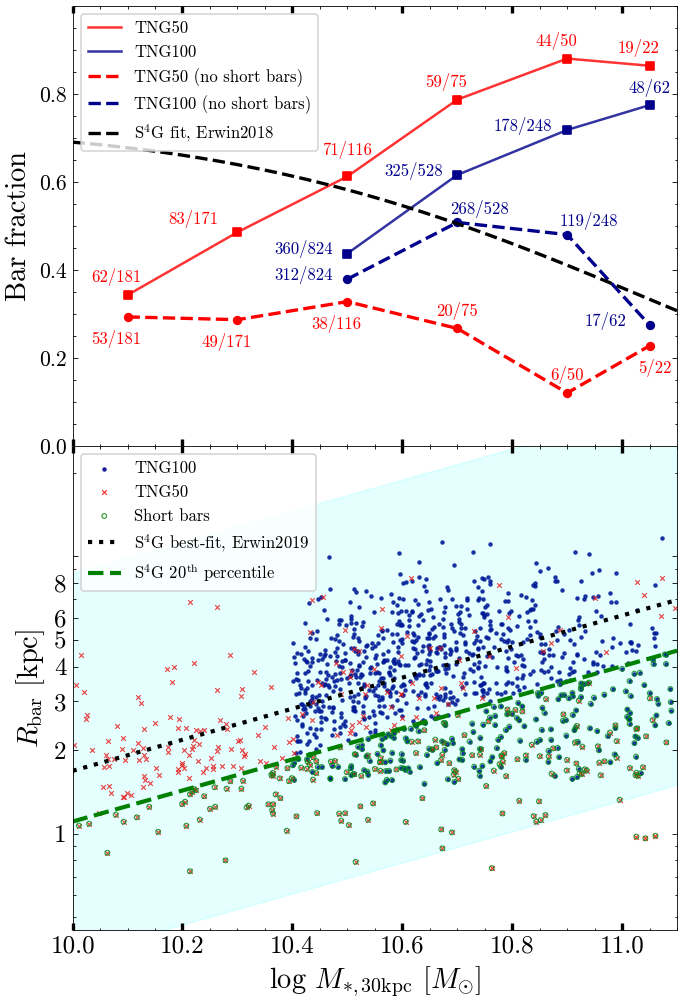

In [51]:
fig,axs=plt.subplots(2,1,sharex=True,dpi=120,figsize=(6.5,10),gridspec_kw={'height_ratios':[1,1.1]})
axs[1].scatter(TNG100_table[TNG100_table['Rbar']>0]['stellar_mass'],TNG100_table[TNG100_table['Rbar']>0]['Rbar'],s=3,c='#00008B',alpha=0.8,label='TNG100')
axs[1].scatter(TNG50_table[TNG50_table['Rbar']>0]['stellar_mass'],TNG50_table[TNG50_table['Rbar']>0]['Rbar'],s=8,c='red',alpha=0.8,marker='x',linewidths=0.7,label='TNG50',)
axs[1].scatter(TNG50_table[(TNG50_table['short20']==0)&(TNG50_table['Rbar']>0)]['stellar_mass'],TNG50_table[(TNG50_table['short20']==0)&(TNG50_table['Rbar']>0)]['Rbar'],
               s=8,c='none',edgecolor='green',alpha=0.8,linewidth=0.7,label='Short bars')

axs[1].scatter(TNG100_table[(TNG100_table['short20']==0)&(TNG100_table['Rbar']>0)]['stellar_mass'],
               TNG100_table[(TNG100_table['short20']==0)&(TNG100_table['Rbar']>0)]['Rbar'],s=8,c='none',edgecolor='green',alpha=0.8,linewidth=0.7)

axs[1].plot(obs90x1,10**fit_y,c='k',linewidth=2.5,linestyle=':',label='S$^{4}$G best-fit, Erwin2019')
axs[1].plot(fS4Gfit_x,S4GRbarlow_20th,c='green',linewidth=2.5,linestyle='--',
            label='S$^{4}\mathrm{G}\ 20^\mathrm{th}\ \mathrm{percentile} $')

axs[1].legend(loc='upper left',fontsize=12,prop = {'size' : 10},frameon=True)

axs[1].fill_between(fS4Gfit_x, np.asarray(S4G_l3sigma),np.asarray(S4G_u3sigma),color='cyan',alpha=0.1)
axs[1].set_ylabel(r'$R_\mathrm{bar}$ [kpc]',fontsize=17)
axs[1].set_yscale('log')

axs[1].set_yticks([1,2,3,4,5,6,8,10])
axs[1].set_yticklabels([1,2,3,4,5,6,8,''],fontsize=15)


axs[0].plot(X_mass,f50allbar,c='red',alpha=0.8,linewidth=1.5,label = 'TNG50')
axs[0].plot(X_mass[2:],f100allbar_update,c='#00008B',alpha=0.8,linewidth=1.5,label = 'TNG100')

axs[0].plot(X_mass,f50normalbar,c='red',label='TNG50 (no short bars)',linestyle='--',linewidth=2)
axs[0].plot(X_mass[2:],f100normalbar_update,c='#00008B',label='TNG100 (no short bars)',linestyle='--',linewidth=2)


axs[0].plot(fS4Gfit_x,fS4Gfit_y,c='k',label='S$^{4}$G fit, Erwin2018',linestyle='--',linewidth=2)



axs[0].scatter(X_mass,f50normalbar,c='red',s=21)
axs[0].scatter(X_mass,f50allbar,c='red',s=19,marker = 's')
axs[0].scatter(X_mass[2:],f100allbar_update,c='#00008B',s=19,marker = 's')
axs[0].scatter(X_mass[2:],f100normalbar_update,c='#00008B',s=21)

axs[0].legend(loc='upper left',fontsize=12,prop = {'size' : 10},frameon=True,ncols=1)
axs[0].set_ylim(0,1)
axs[0].set_xlim(10.0,11.1)
axs[0].set_xticks([10.0,10.2,10.4,10.6,10.8,11.0])
axs[0].set_xticklabels(['','','','','',''],fontsize=15)
axs[0].set_yticks([0.0,0.2,0.4,0.6,0.8])
axs[0].set_yticklabels(['0.0','0.2','0.4','0.6','0.8'],fontsize=13)

axs[1].tick_params(axis="x", which="major", direction="in", width=2, length=4)
axs[0].tick_params(axis="x", which="major", direction="in", width=2, length=4)

numfontsize=10

for i in range(0,len(f100normalbar_update)):
    if i in [0,3]:
        axs[0].text(X_mass[i+2]-0.08,f100normalbar_update[i]-0.01,f'{Num_TNG100_normalbar_update[i]}/{Num_TNG100_disk_update[i]}',ha='center', va='bottom',c='#00008B',fontsize=numfontsize,)
    else:     
        axs[0].text(X_mass[i+2]+0.04,f100normalbar_update[i]+0.01,f'{Num_TNG100_normalbar_update[i]}/{Num_TNG100_disk_update[i]}',ha='center', va='bottom',c='#00008B',fontsize=numfontsize)

for i in range(0,len(f100allbar_update)):
    if i in [0,1,2]:
        axs[0].text(X_mass[i+2]-0.08,f100allbar_update[i]-0.01,f'{Num_TNG100_allbar_update[i]}/{Num_TNG100_disk_update[i]}',ha='center', va='bottom',c='#00008B',fontsize=numfontsize,)
    else:     
        axs[0].text(X_mass[i+2],f100allbar_update[i]+0.02,f'{Num_TNG100_allbar_update[i]}/{Num_TNG100_disk_update[i]}',ha='center', va='bottom',c='#00008B',fontsize=numfontsize)
        
for i in range(0,len(f50normalbar)):
    if i in [0,1,2]: #[0,1,3,5]
        axs[0].text(X_mass[i]-0.02,f50normalbar[i]-0.07,f'{Num_TNG50_normalbar[i]}/{Num_TNG50_disk[i]}',ha='center', va='bottom',c='red',fontsize=numfontsize,)
    elif i in [5]:
        axs[0].text(X_mass[i]+0.01,f50normalbar[i]-0.07,f'{Num_TNG50_normalbar[i]}/{Num_TNG50_disk[i]}',ha='center', va='bottom',c='red',fontsize=numfontsize)
    else:     
        axs[0].text(X_mass[i],f50normalbar[i]+0.02,f'{Num_TNG50_normalbar[i]}/{Num_TNG50_disk[i]}',ha='center', va='bottom',c='red',fontsize=numfontsize)

for i in range(0,len(f50allbar)):
    if i in [1]: #[0,1,3,5]
        axs[0].text(X_mass[i]-0.08,f50allbar[i]+0.01,f'{Num_TNG50_allbar[i]}/{Num_TNG50_disk[i]}',ha='center', va='bottom',c='red',fontsize=numfontsize,)
    elif i in [2]:
        axs[0].text(X_mass[i],f50allbar[i]+0.04,f'{Num_TNG50_allbar[i]}/{Num_TNG50_disk[i]}',ha='center', va='bottom',c='red',fontsize=numfontsize)
    else:     
        axs[0].text(X_mass[i]-0.02,f50allbar[i]+0.02,f'{Num_TNG50_allbar[i]}/{Num_TNG50_disk[i]}',ha='center', va='bottom',c='red',fontsize=numfontsize)

axs[1].set_xticks([10.0,10.2,10.4,10.6,10.8,11.0])
axs[1].set_xticklabels([10.0,10.2,10.4,10.6,10.8,11.0],fontsize=15)  #####
axs[0].set_ylabel('Bar fraction',fontsize=17)
axs[1].set_xlabel(r'log $M_\mathrm{*,30kpc}$ [$M_{\odot}$]',fontsize=17)
axs[1].set_ylim(0.45,25)
fig.subplots_adjust(hspace=0)
plt.savefig('./TNG50vsTNG100vsS4Gselectsimply.png',bbox_inches='tight')